In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("../data/student-mat.csv", sep=";")

df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

Number of rows and columns:
(395, 33)

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [7]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [8]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


In [9]:
print("Data types of each column:")
print(df.dtypes)

Data types of each column:
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object


In [11]:
print("Numerical columns:")
print(df.select_dtypes(include="number").columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(include="object").columns.tolist())

Numerical columns:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Categorical columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


C:\Users\reddy\AppData\Local\Temp\ipykernel_16160\3735327654.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include="object").columns.tolist())


In [12]:
for column in df.select_dtypes(include=["object"]).columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


school:
school
GP    349
MS     46
Name: count, dtype: int64

sex:
sex
F    208
M    187
Name: count, dtype: int64

address:
address
U    307
R     88
Name: count, dtype: int64

famsize:
famsize
GT3    281
LE3    114
Name: count, dtype: int64

Pstatus:
Pstatus
T    354
A     41
Name: count, dtype: int64

Mjob:
Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64

Fjob:
Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64

reason:
reason
course        145
home          109
reputation    105
other          36
Name: count, dtype: int64

guardian:
guardian
mother    273
father     90
other      32
Name: count, dtype: int64

schoolsup:
schoolsup
no     344
yes     51
Name: count, dtype: int64

famsup:
famsup
yes    242
no     153
Name: count, dtype: int64

paid:
paid
no     214
yes    181
Name: count, dtype: int64

activities:
activities
yes    201
no     194
Name: count, dty

C:\Users\reddy\AppData\Local\Temp\ipykernel_16160\2494744609.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df.select_dtypes(include=["object"]).columns:


In [13]:
print("Final grade statistics:")
print(df["G3"].describe())

Final grade statistics:
count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


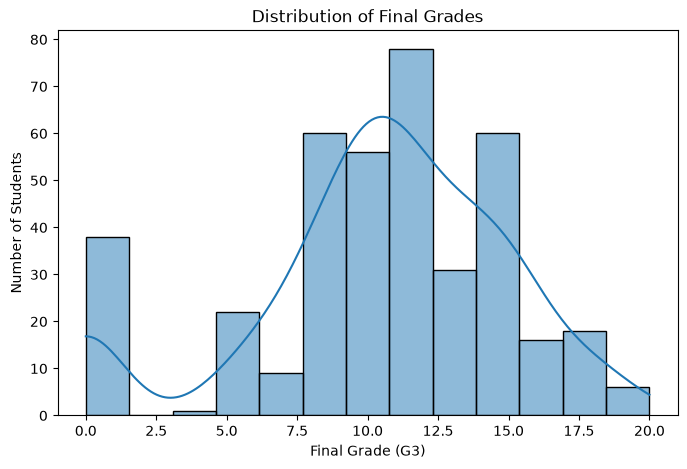

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(df["G3"], kde=True)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.savefig("../visualizations/grade_distribution.png")
plt.show()


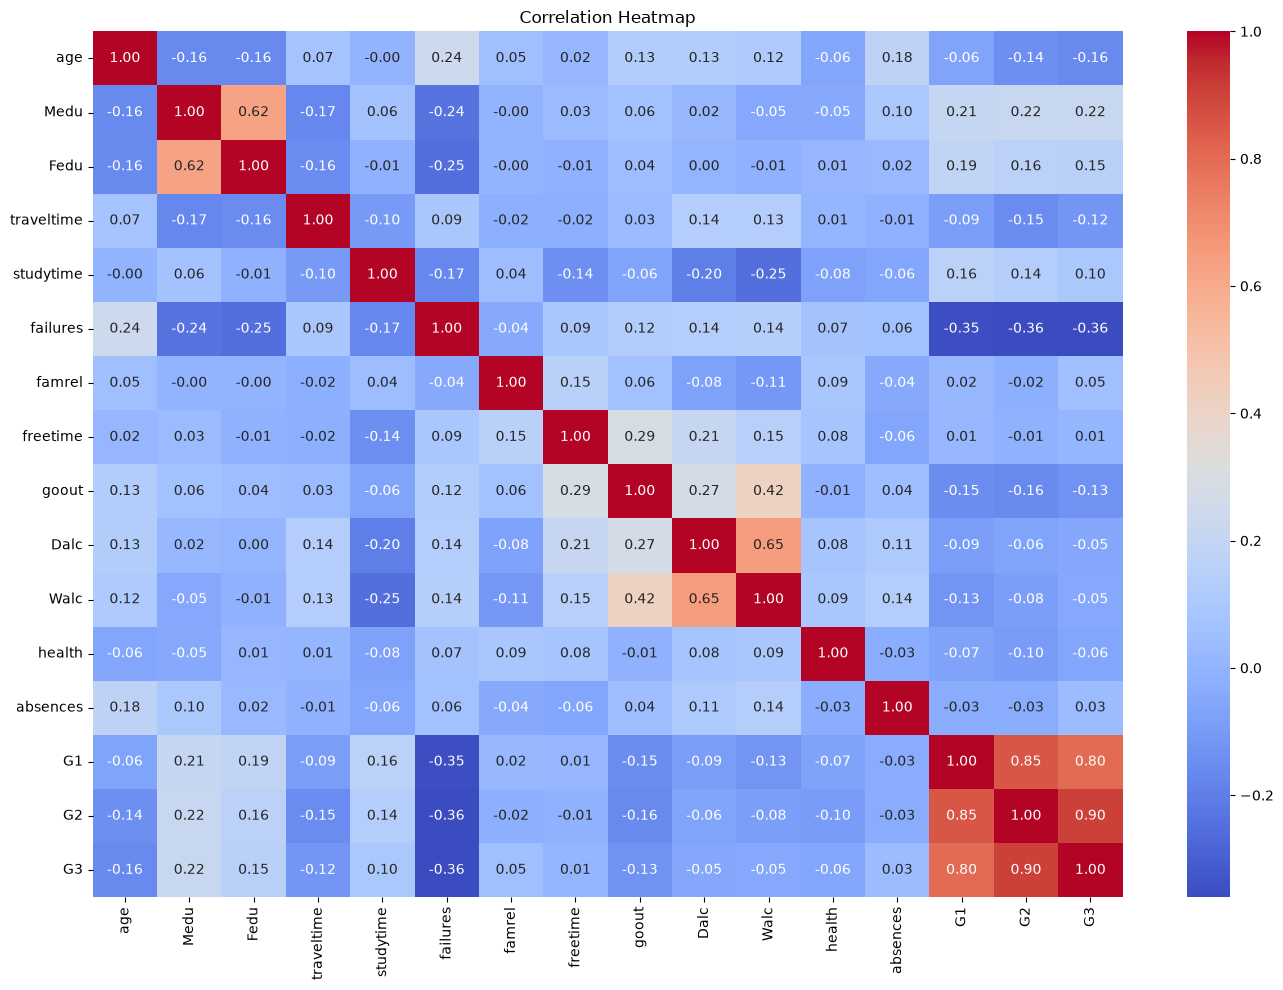

In [16]:

plt.figure(figsize=(14, 10))

correlation = df.select_dtypes(include="number").corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig("../visualizations/correlation_heatmap.png")
plt.show()

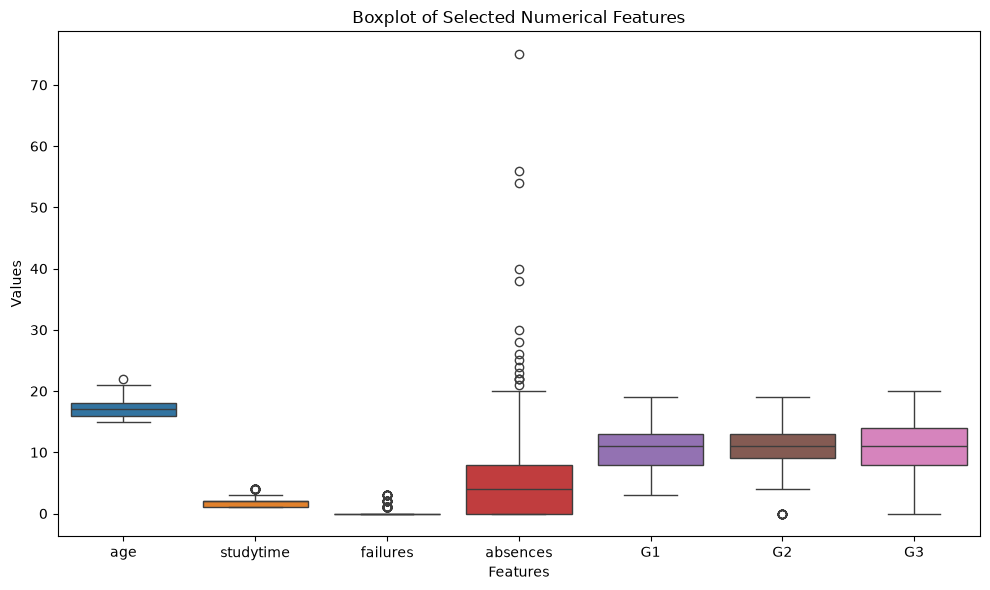

In [17]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[["age", "studytime", "failures", "absences", "G1", "G2", "G3"]])

plt.title("Boxplot of Selected Numerical Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.tight_layout()
plt.savefig("../visualizations/boxplot_features.png")
plt.show()

In [18]:
X = df.drop("G3", axis=1)
y = df["G3"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (395, 32)
y shape: (395,)


In [19]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

print("\nFirst 5 rows:")
display(X_encoded.head())

Original X shape: (395, 32)
Encoded X shape: (395, 41)

First 5 rows:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


In [20]:
print(X_encoded.dtypes.value_counts())

bool     26
int64    15
Name: count, dtype: int64


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (316, 41)
y_train: (316,)

Testing data:
X_test: (79, 41)
y_test: (79,)


In [22]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [23]:
# Make predictions on the test data
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[ 6.00160699 11.52847844  2.86643677  8.79663116  8.55310627 11.88964112
 19.09674195  7.17307901  7.4050707  12.31153657]


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation
-----------------
MAE : 1.6466656197147518
MSE : 5.656642833231225
RMSE: 2.3783697847961376
R²  : 0.7241341236974019


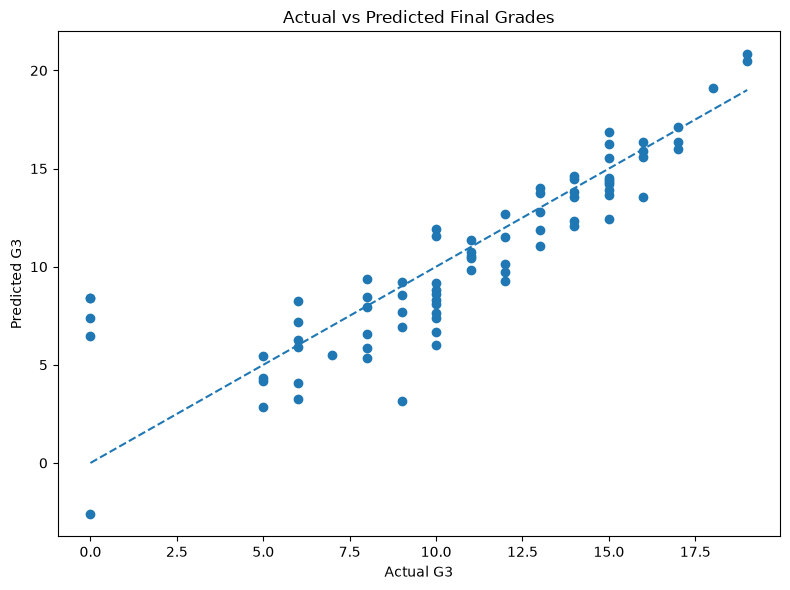

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Final Grades")

plt.tight_layout()
plt.savefig("../visualizations/actual_vs_predicted.png")
plt.show()

In [26]:
comparison = pd.DataFrame({
    "Actual G3": y_test.values,
    "Predicted G3": y_pred
})

comparison["Error"] = comparison["Actual G3"] - comparison["Predicted G3"]

comparison.head(10)

,Actual G3,Predicted G3,Error
0,10,6.001607,3.998393
1,12,11.528478,0.471522
2,5,2.866437,2.133563
3,10,8.796631,1.203369
4,9,8.553106,0.446894
5,13,11.889641,1.110359
6,18,19.096742,-1.096742
7,6,7.173079,-1.173079
8,0,7.405071,-7.405071
9,14,12.311537,1.688463


In [27]:
comparison.to_csv(
    "../visualizations/actual_vs_predicted.csv",
    index=False
)

print("Comparison saved successfully!")

Comparison saved successfully!


In [28]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [29]:
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions:")
print(rf_pred[:10])

Random Forest predictions:
[ 8.24  11.77   6.725  9.56   8.82  12.85  18.685  6.855  7.005 13.345]


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Random Forest metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Evaluation")
print("------------------------")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)


Random Forest Evaluation
------------------------
MAE : 1.1734177215189876
MSE : 3.8676405063291144
RMSE: 1.9666317668361595
R²  : 0.8113810489794643


In [31]:
comparison_models = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "MSE": [mse, rf_mse],
    "RMSE": [rmse, rf_rmse],
    "R2": [r2, rf_r2]
})

comparison_models

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,1.646666,5.656643,2.378370,0.724134
1,Random Forest,1.173418,3.867641,1.966632,0.811381


In [32]:
# Select the model with the best R² score
if rf_r2 > r2:
    best_model = rf_model
    best_model_name = "Random Forest"
    best_r2 = rf_r2
else:
    best_model = model
    best_model_name = "Linear Regression"
    best_r2 = r2

print("Best Model:", best_model_name)
print("Best R²:", best_r2)

Best Model: Random Forest
Best R²: 0.8113810489794643


In [33]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/best_student_grade_model.pkl")

print("Best model saved successfully!")


Best model saved successfully!


In [34]:
def predict_student_grade(student_data):
    # Convert the input into a DataFrame
    student_df = pd.DataFrame([student_data])

    # Apply the same one-hot encoding used during training
    student_encoded = pd.get_dummies(student_df)

    # Make sure the new data has exactly the same columns as training data
    student_encoded = student_encoded.reindex(
        columns=X_encoded.columns,
        fill_value=0
    )

    # Predict final grade
    prediction = best_model.predict(student_encoded)

    return prediction[0]

In [35]:
sample_student = X.iloc[0].to_dict()

predicted_grade = predict_student_grade(sample_student)

print("Predicted Final Grade:", predicted_grade)

Predicted Final Grade: 6.39


In [36]:
new_student = {
    "school": "GP",
    "sex": "F",
    "age": 17,
    "address": "U",
    "famsize": "GT3",
    "Pstatus": "A",
    "Medu": 3,
    "Fedu": 3,
    "Mjob": "teacher",
    "Fjob": "other",
    "reason": "course",
    "guardian": "mother",
    "traveltime": 1,
    "studytime": 3,
    "failures": 0,
    "schoolsup": "no",
    "famsup": "yes",
    "paid": "no",
    "activities": "yes",
    "nursery": "yes",
    "higher": "yes",
    "internet": "yes",
    "romantic": "no",
    "famrel": 4,
    "freetime": 3,
    "goout": 3,
    "Dalc": 1,
    "Walc": 1,
    "health": 5,
    "absences": 4,
    "G1": 14,
    "G2": 15
}

In [37]:
predicted_grade = predict_student_grade(new_student)

print("Predicted Final Grade (G3):", round(predicted_grade, 2))

Predicted Final Grade (G3): 15.44


In [1]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/best_student_grade_model.pkl")

print("Best model saved successfully!")

NameError: name 'best_model' is not defined

In [2]:
Get-Item models\best_student_grade_model.pkl | Select-Object Name,Length

SyntaxError: unexpected character after line continuation character (2749321195.py, line 1)